## 02 Exploratory Data Analysis 

**Input:**  data/ventas_clean.csv (produced by 01_data_production.ipynb)


## Setup

In [1]:
import os
import pathlib
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde

ROOT = pathlib.Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

C = dict(
    bg ="#0A0E17", surface="#111827", surf2="#1A2235", border="#1E2D45",
    accent="#00E5A0", gold="#F5C842", red="#FF4D6A", blue="#4D9FFF",
    purple="#A78BFA", text="#E8EDF5", muted="#6B7A99",
)
YEAR_C = {2023: C["blue"], 2024: C["accent"], 2025: C["gold"], 2026: C["red"]}

mpl.rcParams.update({
    "figure.facecolor": C["bg"], "axes.facecolor": C["surface"],
    "axes.edgecolor": C["border"],"axes.labelcolor": C["muted"],
    "axes.titlecolor": C["text"], "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["border"],
    "grid.linewidth": 0.6, "grid.alpha": 0.8,
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.facecolor": C["surf2"], "legend.edgecolor": C["border"],
    "legend.labelcolor": C["text"], "legend.fontsize": 9,
    "text.color": C["text"], "font.family": "DejaVu Sans",
    "figure.dpi": 150, "lines.linewidth": 2,
})

def spine_style(ax):
    ax.spines["left"].set_color(C["border"])
    ax.spines["bottom"].set_color(C["border"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=C["muted"])

def fmt_ars(v):
    if v >= 1_000_000:
        return f"${v/1_000_000:.1f}M"
    if v >= 1_000:
        return f"${v/1_000:.0f}K"
    return f"${v:.0f}"

os.makedirs(ROOT / "plots", exist_ok=True)

df = pd.read_csv(ROOT / "data" / "ventas_clean.csv", parse_dates=["date"])
df["year_month"] = pd.to_datetime(df["date"]).dt.to_period("M")

print(f"Dataset loaded: {len(df):,} orders")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Columns: {list(df.columns)}")


Dataset loaded: 353 orders
Date range: 2023-01-06 -> 2026-04-01
Columns: ['order_id', 'date', 'unit_price', 'quantity', 'gross_revenue', 'net_revenue', 'product_title', 'item_id', 'province', 'city', 'source', 'year', 'month', 'quarter', 'day_of_week', 'is_weekend', 'year_month', 'revenue_per_unit', 'ml_fee_pct', 'cpi_index', 'gross_revenue_real', 'unit_price_real']


## Revenue Trend - Nominal vs Real

In [2]:
monthly = (
    df.groupby("year_month")
    .agg(
        gross_nominal = ("gross_revenue", "sum"),
        gross_real = ("gross_revenue_real", "sum"),
        orders = ("order_id", "count"),
        median_ticket = ("unit_price", "median"),
        median_ticket_r = ("unit_price_real", "median"),
    )
    .reset_index()
)
monthly["date"] = monthly["year_month"].dt.to_timestamp()

# Month-over-month growth rates
monthly["mom_nominal"] = monthly["gross_nominal"].pct_change() * 100
monthly["mom_real"] = monthly["gross_real"].pct_change() * 100
monthly.head(3)

,year_month,gross_nominal,gross_real,orders,median_ticket,median_ticket_r,date,mom_nominal,mom_real
0,2023-01,22378.0,22378.000000,22,974.0,974.000000,2023-01-01,NaN,NaN
1,2023-02,12487.0,11780.188679,13,999.0,942.452830,2023-02-01,-44.199660,-47.358170
2,2023-03,15888.0,14060.674714,12,1199.0,1061.099508,2023-03-01,27.236326,19.358655


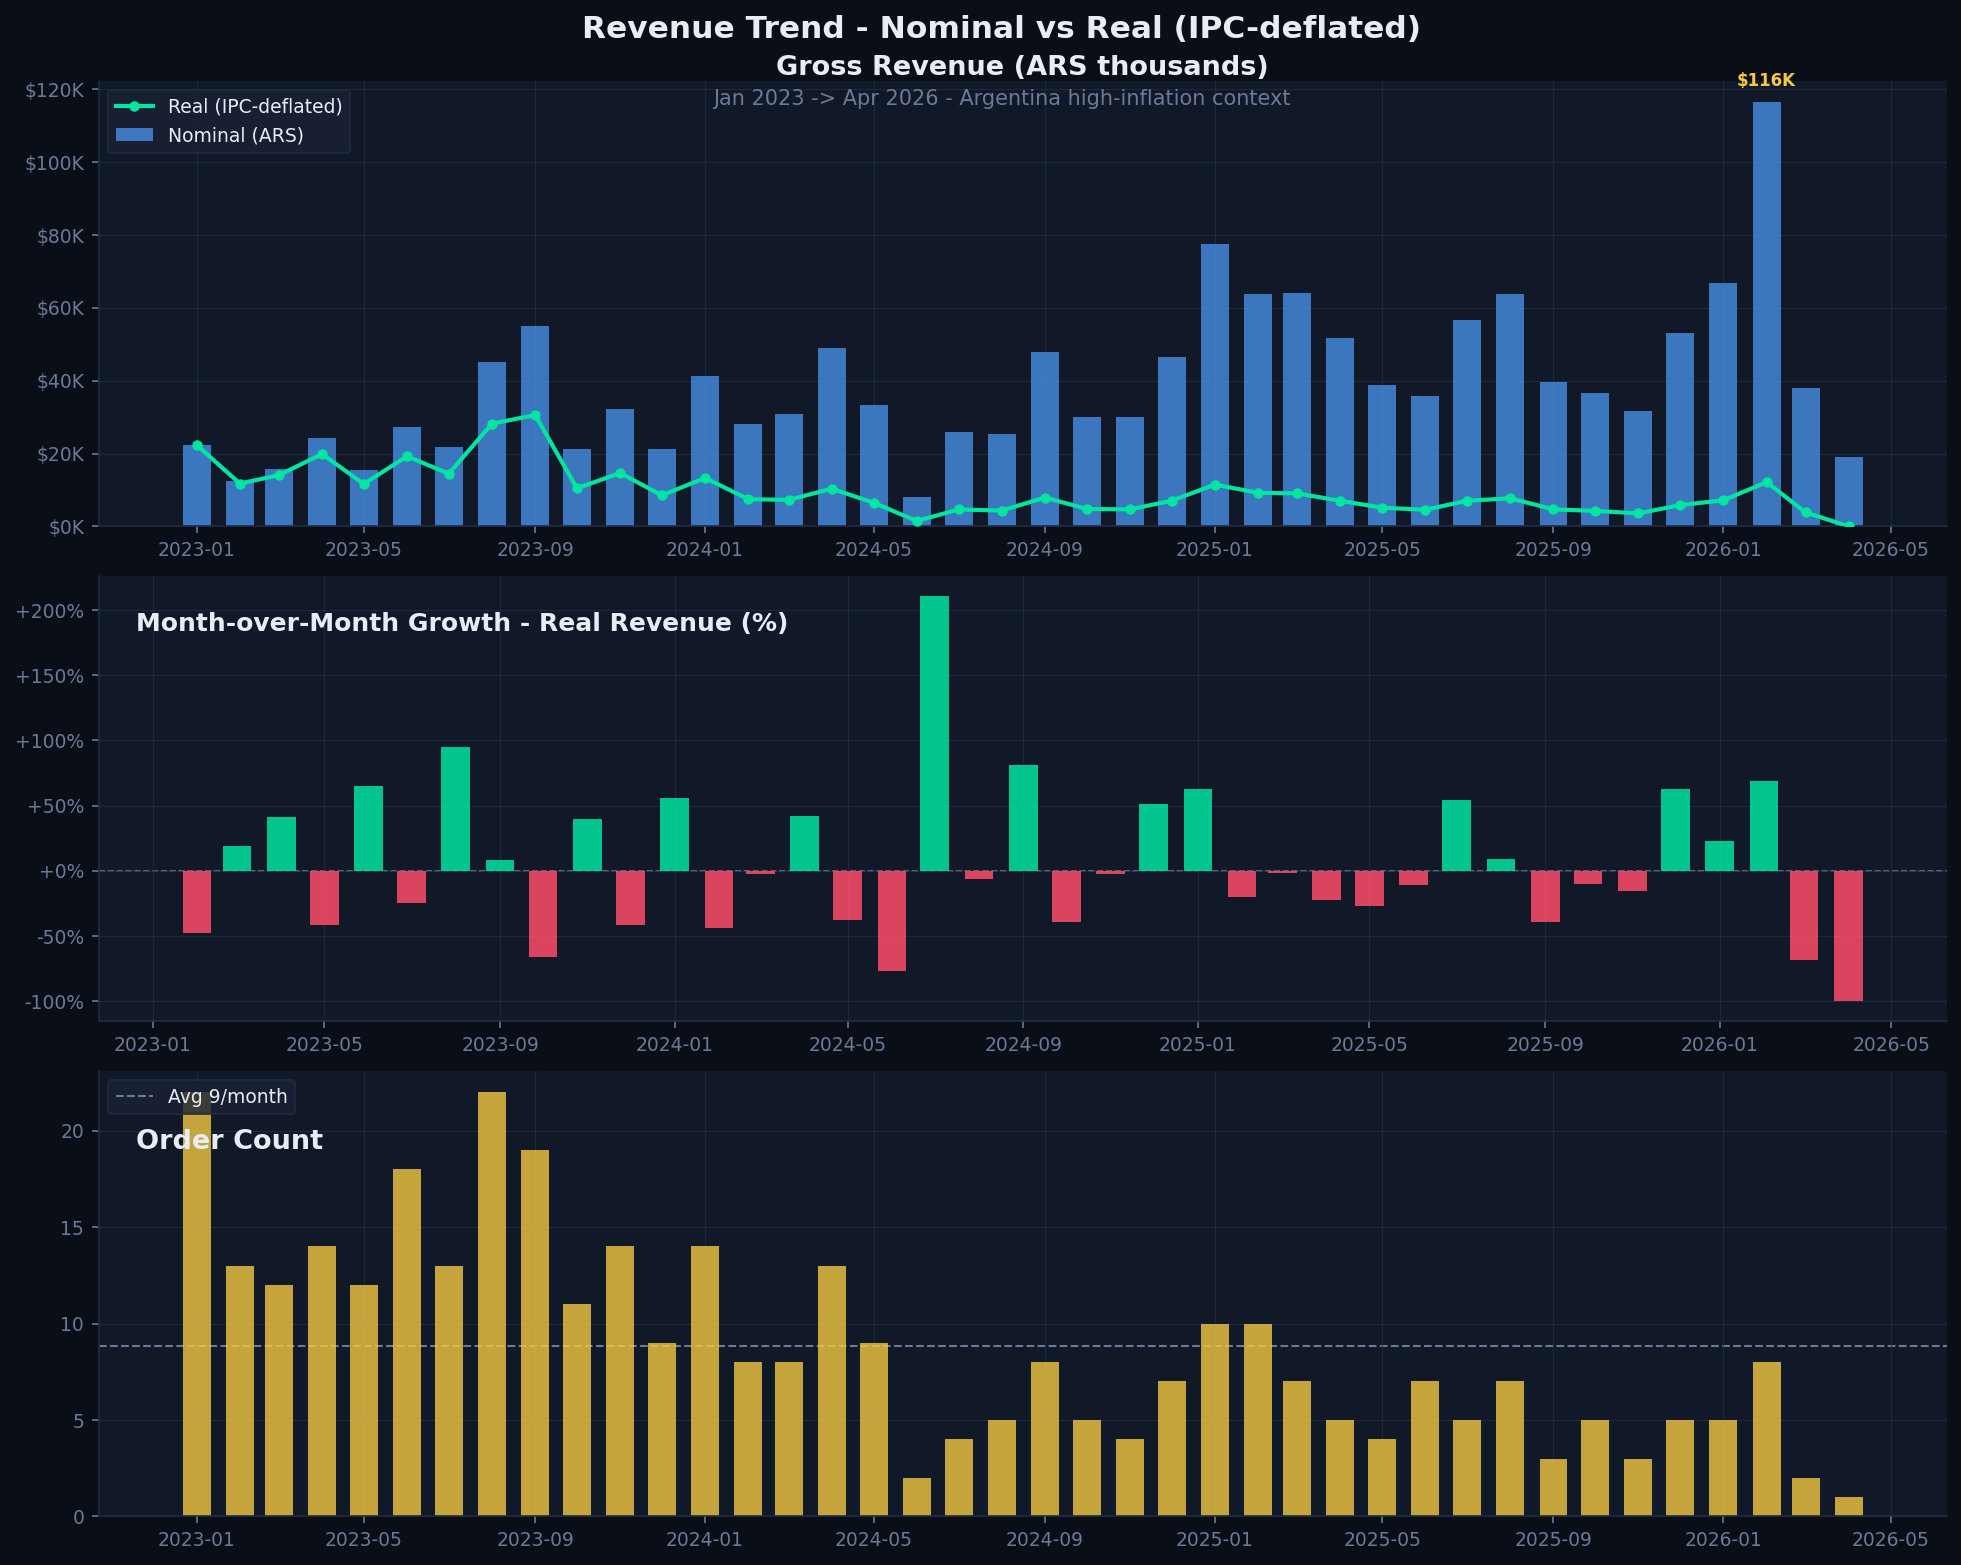

Nominal revenue growth (full period): +-15%
Real revenue growth (full period): -100%

Best month (nominal): Feb 2026
Worst month (nominal): Jun 2024


In [3]:
fig = plt.figure(figsize=(14, 11), facecolor=C["bg"])
fig.text(0.5, 0.98, "Revenue Trend - Nominal vs Real (IPC-deflated)",
         ha="center", va="top", fontsize=15, fontweight="bold", color=C["text"])
fig.text(0.5, 0.935,
         f"{df['date'].min().strftime('%b %Y')} -> {df['date'].max().strftime('%b %Y')} - Argentina high-inflation context",
         ha="center", va="top", fontsize=10, color=C["muted"])

ax1 = fig.add_axes([0.07, 0.67, 0.88, 0.27])
ax2 = fig.add_axes([0.07, 0.37, 0.88, 0.27])
ax3 = fig.add_axes([0.07, 0.07, 0.88, 0.27]) 
BAR_W = 20

# Panel 1: Nominal bars + real line 
ax1.bar(monthly["date"], monthly["gross_nominal"] / 1e3, width=BAR_W,
        color=C["blue"], alpha=0.7, zorder=2, label="Nominal (ARS)")
if monthly["gross_real"].notna().any():
    ax1.plot(monthly["date"], monthly["gross_real"] / 1e3,
             color=C["accent"], linewidth=2, marker="o", markersize=4,
             zorder=3, label="Real (IPC-deflated)")
peak = monthly.loc[monthly["gross_nominal"].idxmax()]
ax1.annotate(fmt_ars(peak["gross_nominal"]),
             xy=(peak["date"], peak["gross_nominal"] / 1e3),
             xytext=(0, 8), textcoords="offset points",
             ha="center", fontsize=8, color=C["gold"], fontweight="bold")
ax1.set_title("Gross Revenue (ARS thousands)", pad=-20)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax1.legend(loc="upper left")
spine_style(ax1)
ax1.set_facecolor(C["surface"])

#Panel 2: MoM real growth 
colors_mom = [C["accent"] if v >= 0 else C["red"]
              for v in monthly["mom_real"].fillna(0)]
ax2.bar(monthly["date"], monthly["mom_real"], width=BAR_W,
        color=colors_mom, alpha=0.85, zorder=2)
ax2.axhline(0, color=C["muted"], linewidth=0.8, linestyle="--", zorder=1)
ax2.text(0.02, 0.92, "Month-over-Month Growth - Real Revenue (%)",
         transform=ax2.transAxes, fontsize=12, fontweight="bold",
         color=C["text"], va="top")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))
spine_style(ax2)
ax2.set_facecolor(C["surface"])

#Panel 3: Orders 
ax3.bar(monthly["date"], monthly["orders"], width=BAR_W,
        color=C["gold"], alpha=0.8, zorder=2)
avg_orders = monthly["orders"].mean()
ax3.axhline(avg_orders, color=C["muted"], linewidth=1, linestyle="--",
            label=f"Avg {avg_orders:.0f}/month", zorder=1)
ax3.text(0.02, 0.87, "Order Count",
         transform=ax3.transAxes, fontsize=13, fontweight="bold",
         color=C["text"], va="top")
ax3.legend(loc="upper left")
spine_style(ax3)
ax3.set_facecolor(C["surface"])

plt.savefig(ROOT / "plots" / "05_nominal_vs_real.png", dpi=150,
            bbox_inches="tight", facecolor=C["bg"])
plt.show()

nominal_growth = (monthly["gross_nominal"].iloc[-1] / monthly["gross_nominal"].iloc[0] - 1) * 100
real_growth = (monthly["gross_real"].dropna().iloc[-1] / monthly["gross_real"].dropna().iloc[0] - 1) * 100
print(f"Nominal revenue growth (full period): +{nominal_growth:.0f}%")
print(f"Real revenue growth (full period): {real_growth:+.0f}%")
print(f"\nBest month (nominal): {monthly.loc[monthly['gross_nominal'].idxmax(), 'date'].strftime('%b %Y')}")
print(f"Worst month (nominal): {monthly.loc[monthly['gross_nominal'].idxmin(), 'date'].strftime('%b %Y')}")


## Seasonality Decomposition

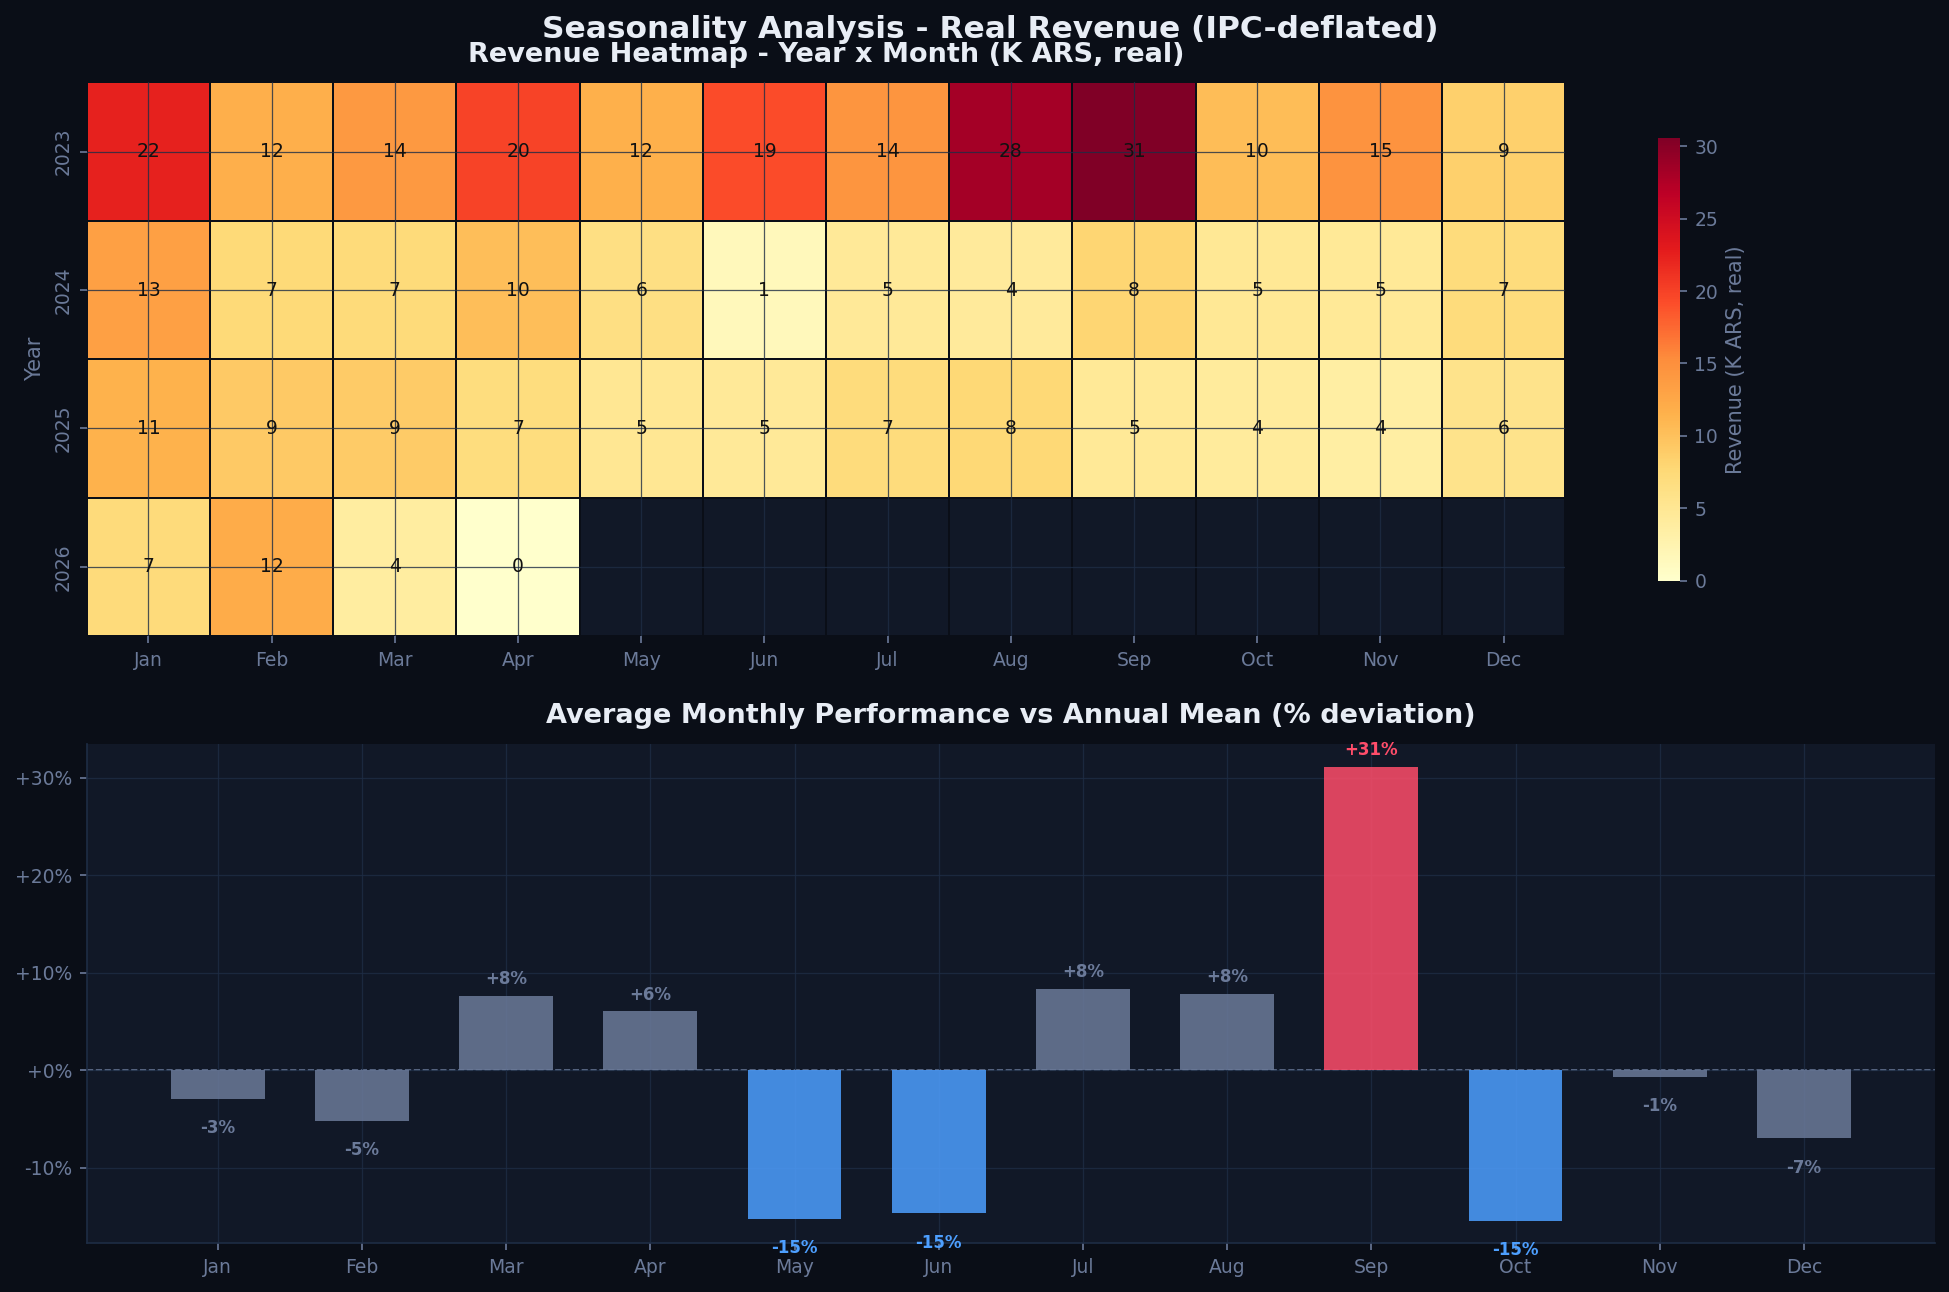

Peak months: ['Sep', 'Jul'] (+31%, +8%)
Trough months: ['Oct', 'May'] (-15%, -15%)


In [4]:
pivot = (
    df.groupby(["year", "month"])["gross_revenue_real"]
    .sum()
    .reset_index()
    .pivot(index="year", columns="month", values="gross_revenue_real")
)
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
pivot.columns = MONTH_NAMES

by_month = df.groupby("month")["gross_revenue_real"].mean().reset_index()
by_month["month_name"] = MONTH_NAMES
grand_mean = by_month["gross_revenue_real"].mean()
by_month["vs_avg"] = (by_month["gross_revenue_real"] / grand_mean - 1) * 100

fig = plt.figure(figsize=(14, 9), facecolor=C["bg"])
fig.text(0.5, 0.98, "Seasonality Analysis - Real Revenue (IPC-deflated)",
         ha="center", va="top", fontsize=15, fontweight="bold", color=C["text"])

ax1 = fig.add_axes([0.07, 0.52, 0.88, 0.41])
ax2 = fig.add_axes([0.07, 0.07, 0.88, 0.37])

# Heatmap
pivot_plot = pivot / 1e3
sns.heatmap(
    pivot_plot, ax=ax1,
    cmap="YlOrRd",
    annot=True, fmt=".0f",
    linewidths=0.8, linecolor=C["bg"],
    cbar_kws={"label": "Revenue (K ARS, real)", "shrink": 0.8},
    annot_kws={"size": 9, "color": "#111"},
)
ax1.set_title("Revenue Heatmap - Year x Month (K ARS, real)", pad=10)
ax1.set_xlabel("")
ax1.set_ylabel("Year", color=C["muted"])
ax1.tick_params(colors=C["muted"])
ax1.set_facecolor(C["surface"])

# Monthly deviation bars 
bar_colors = [C["red"] if v >= 10 else C["blue"] if v <= -10 else C["muted"]
              for v in by_month["vs_avg"]]
bars = ax2.bar(by_month["month_name"], by_month["vs_avg"],
               color=bar_colors, alpha=0.85, width=0.65, zorder=2)
ax2.axhline(0, color=C["muted"], linewidth=0.8, linestyle="--", zorder=1)
ax2.set_title("Average Monthly Performance vs Annual Mean (% deviation)", pad=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))
ax2.set_facecolor(C["surface"])
spine_style(ax2)

for bar, (_, row) in zip(bars, by_month.iterrows()):
    offset = 1.2 if row["vs_avg"] >= 0 else -3.5
    color  = C["red"] if row["vs_avg"] >= 10 else C["blue"] if row["vs_avg"] <= -10 else C["muted"]
    ax2.text(bar.get_x() + bar.get_width()/2, row["vs_avg"] + offset,
             f"{row['vs_avg']:+.0f}%", ha="center", fontsize=8,
             color=color, fontweight="bold")

plt.savefig(ROOT / "plots" / "06_seasonality.png", dpi=150,
            bbox_inches="tight", facecolor=C["bg"])
plt.show()

top2    = by_month.nlargest(2, "vs_avg")[["month_name","vs_avg"]]
bottom2 = by_month.nsmallest(2, "vs_avg")[["month_name","vs_avg"]]
print(f"Peak months: {top2['month_name'].tolist()} ({top2['vs_avg'].values[0]:+.0f}%, {top2['vs_avg'].values[1]:+.0f}%)")
print(f"Trough months: {bottom2['month_name'].tolist()} ({bottom2['vs_avg'].values[0]:+.0f}%, {bottom2['vs_avg'].values[1]:+.0f}%)")


## Day-of-Week and Intraweek Patterns

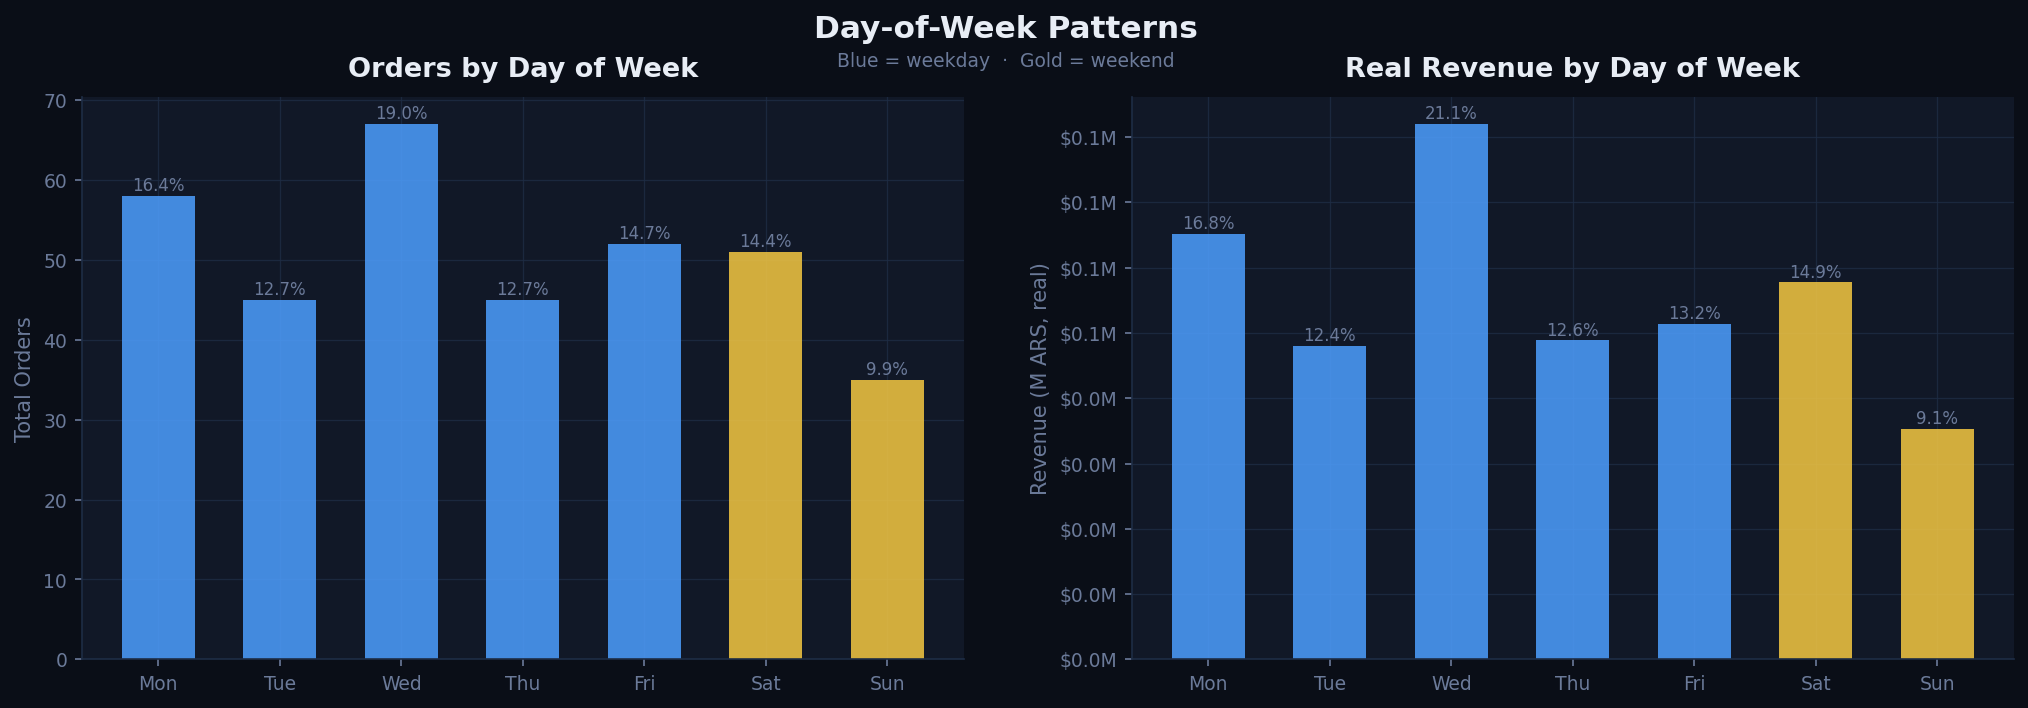

Best day: Wed
Worst day: Sun
Weekend share: 24.4% of orders


In [5]:
DOW_NAMES = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

by_dow = (
    df.groupby("day_of_week")
    .agg(orders=("order_id","count"), revenue=("gross_revenue_real","sum"))
    .reset_index()
)
by_dow["dow_name"] = by_dow["day_of_week"].map(dict(enumerate(DOW_NAMES)))
by_dow["orders_pct"] = by_dow["orders"] / by_dow["orders"].sum() * 100
by_dow["rev_pct"] = by_dow["revenue"] / by_dow["revenue"].sum() * 100

fig = plt.figure(figsize=(14, 5), facecolor=C["bg"])
fig.text(0.5, 0.98, "Day-of-Week Patterns",
         ha="center", va="top", fontsize=15, fontweight="bold", color=C["text"])
fig.text(0.5, 0.93, "Blue = weekday  ·  Gold = weekend",
         ha="center", va="top", fontsize=9, color=C["muted"])

ax1 = fig.add_axes([0.06, 0.12, 0.42, 0.75])
ax2 = fig.add_axes([0.56, 0.12, 0.42, 0.75])

dow_colors = [C["gold"] if i >= 5 else C["blue"] for i in range(7)]

# Orders
bars1 = ax1.bar(by_dow["dow_name"], by_dow["orders"],
                color=dow_colors, alpha=0.85, width=0.6, zorder=2)
for bar, (_, row) in zip(bars1, by_dow.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + by_dow["orders"].max() * 0.01,
             f"{row['orders_pct']:.1f}%",
             ha="center", fontsize=8, color=C["muted"])
ax1.set_title("Orders by Day of Week", pad=10)
ax1.set_ylabel("Total Orders", color=C["muted"])
ax1.set_facecolor(C["surface"])
spine_style(ax1)

# Revenue
bars2 = ax2.bar(by_dow["dow_name"], by_dow["revenue"] / 1e6,
                color=dow_colors, alpha=0.85, width=0.6, zorder=2)
for bar, (_, row) in zip(bars2, by_dow.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + by_dow["revenue"].max() / 1e6 * 0.01,
             f"{row['rev_pct']:.1f}%",
             ha="center", fontsize=8, color=C["muted"])
ax2.set_title("Real Revenue by Day of Week", pad=10)
ax2.set_ylabel("Revenue (M ARS, real)", color=C["muted"])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))
ax2.set_facecolor(C["surface"])
spine_style(ax2)

plt.savefig(ROOT / "plots" / "07_day_of_week.png", dpi=150,
            bbox_inches="tight", facecolor=C["bg"])
plt.show()

best_day = by_dow.loc[by_dow["orders"].idxmax(), "dow_name"]
worst_day = by_dow.loc[by_dow["orders"].idxmin(), "dow_name"]
wknd_pct = by_dow[by_dow["day_of_week"] >= 5]["orders_pct"].sum()
print(f"Best day: {best_day}")
print(f"Worst day: {worst_day}")
print(f"Weekend share: {wknd_pct:.1f}% of orders")


## Pricing Analysis

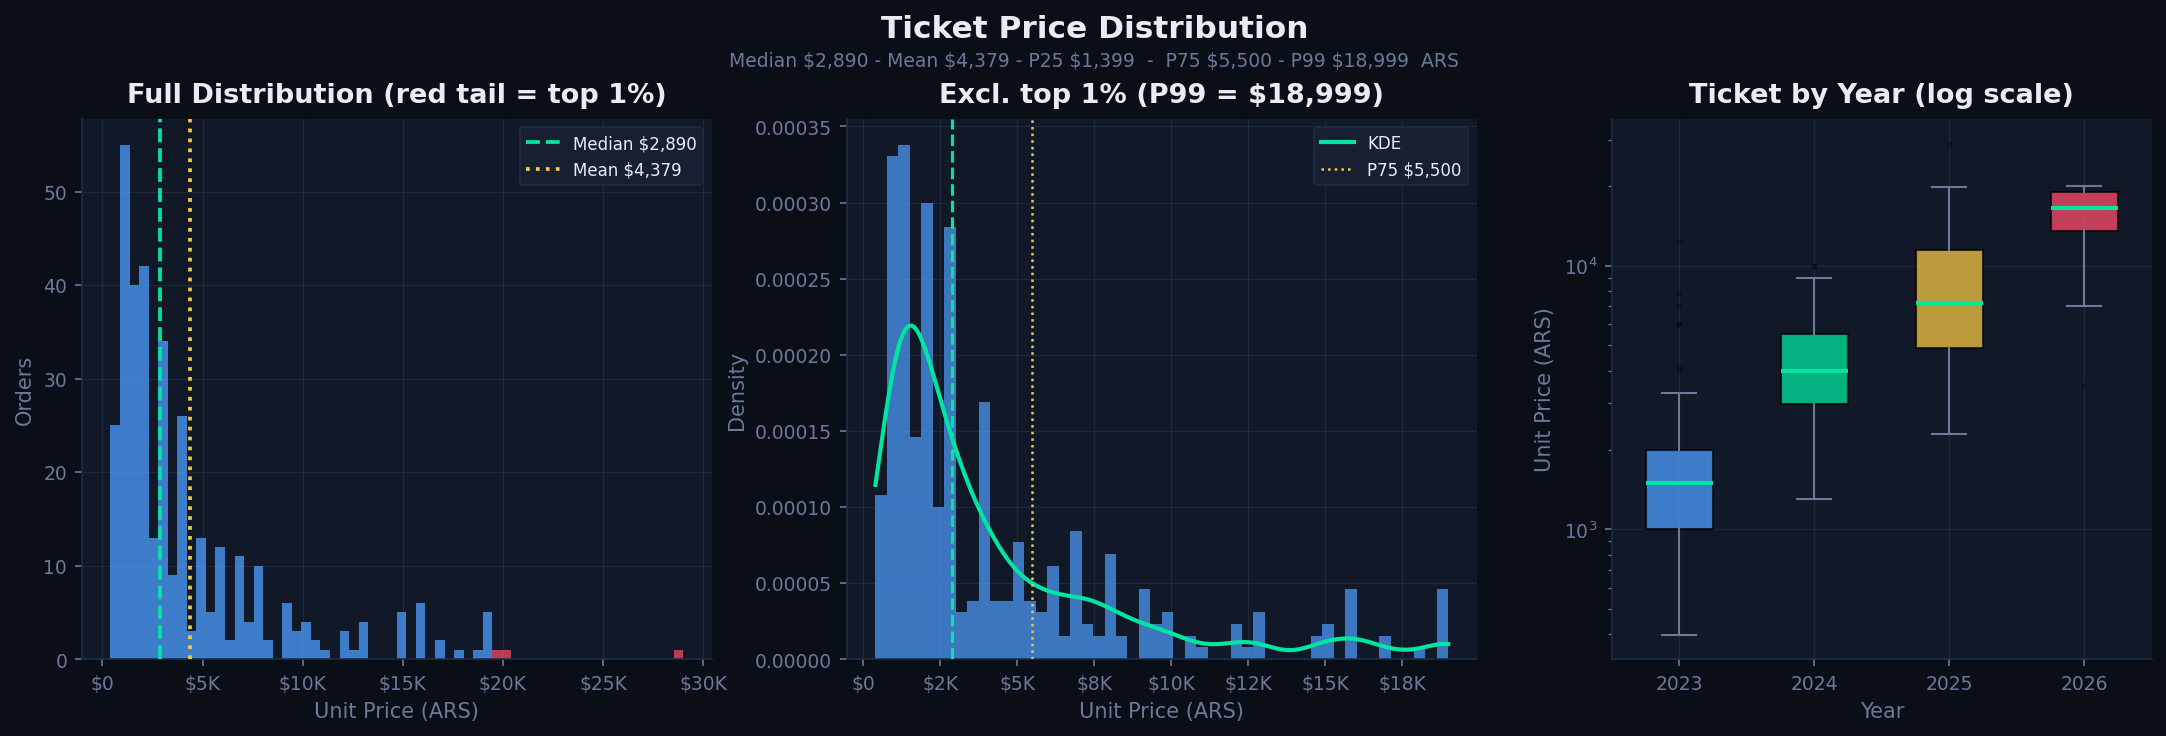

Median: $2,890 ARS | Mean: $4,379 ARS
P25: $1,399 ARS | P75: $5,500 ARS | IQR: $4,101
P99: $18,999 ARS


In [6]:
p99 = df["unit_price"].quantile(0.99)
p75 = df["unit_price"].quantile(0.75)
p25 = df["unit_price"].quantile(0.25)
med = df["unit_price"].median()
mean = df["unit_price"].mean()

fig = plt.figure(figsize=(15, 5), facecolor=C["bg"])
fig.text(0.5, 0.98, "Ticket Price Distribution",
         ha="center", va="top", fontsize=15, fontweight="bold", color=C["text"])
fig.text(0.5, 0.93,
         f"Median ${med:,.0f} - Mean ${mean:,.0f} - P25 ${p25:,.0f}  -  P75 ${p75:,.0f} - P99 ${p99:,.0f}  ARS",
         ha="center", va="top", fontsize=9, color=C["muted"])

ax1 = fig.add_axes([0.05, 0.12, 0.28, 0.72])
ax2 = fig.add_axes([0.39, 0.12, 0.28, 0.72])
ax3 = fig.add_axes([0.73, 0.12, 0.24, 0.72])

# Full distribution
n1, bins1, patches1 = ax1.hist(df["unit_price"], bins=60,
                                color=C["blue"], alpha=0.75, edgecolor="none", zorder=2)
for patch, left in zip(patches1, bins1[:
    -1]):
    if left >= p99:
        patch.set_facecolor(C["red"])
        patch.set_alpha(0.7)
ax1.axvline(med, color=C["accent"], lw=1.8, ls="--", label=f"Median ${med:,.0f}", zorder=3)
ax1.axvline(mean, color=C["gold"], lw=1.8, ls=":", label=f"Mean ${mean:,.0f}", zorder=3)
ax1.set_title("Full Distribution (red tail = top 1%)", pad=8)
ax1.set_xlabel("Unit Price (ARS)", color=C["muted"])
ax1.set_ylabel("Orders", color=C["muted"])
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e3:.0f}K" if x >= 1000 else f"${x:.0f}"))
ax1.legend(fontsize=8)
ax1.set_facecolor(C["surface"])
spine_style(ax1)

# Clipped + KDE
df_clip = df[df["unit_price"] <= p99]["unit_price"]
ax2.hist(df_clip, bins=50, color=C["blue"], alpha=0.7,
         edgecolor="none", zorder=2, density=True)
kde = gaussian_kde(df_clip, bw_method=0.18)
x_k = np.linspace(df_clip.min(), df_clip.max(), 400)
ax2.plot(x_k, kde(x_k), color=C["accent"], lw=2, zorder=3, label="KDE")
ax2.axvline(med, color=C["accent"], lw=1.5, ls="--", zorder=3)
ax2.axvline(p75, color=C["gold"], lw=1.2, ls=":", label=f"P75 ${p75:,.0f}", zorder=3)
ax2.set_title(f"Excl. top 1% (P99 = ${p99:,.0f})", pad=8)
ax2.set_xlabel("Unit Price (ARS)", color=C["muted"])
ax2.set_ylabel("Density", color=C["muted"])
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e3:.0f}K" if x >= 1000 else f"${x:.0f}"))
ax2.legend(fontsize=8)
ax2.set_facecolor(C["surface"])
spine_style(ax2)

# Box per year
years = sorted(df["year"].dropna().unique().astype(int))
data_by_year = [df[df["year"] == y]["unit_price"].dropna().values for y in years]
bp = ax3.boxplot(data_by_year, patch_artist=True, widths=0.5,
                 medianprops=dict(color=C["accent"], linewidth=2),
                 whiskerprops=dict(color=C["muted"]),
                 capprops=dict(color=C["muted"]),
                 flierprops=dict(marker=".", color=C["muted"], alpha=0.3, markersize=3))
for patch, yr in zip(bp["boxes"], years):
    patch.set_facecolor(YEAR_C.get(yr, C["blue"]))
    patch.set_alpha(0.75)
ax3.set_xticklabels(years)
ax3.set_yscale("log")
ax3.set_title("Ticket by Year (log scale)", pad=8)
ax3.set_xlabel("Year", color=C["muted"])
ax3.set_ylabel("Unit Price (ARS)", color=C["muted"])
ax3.set_facecolor(C["surface"])
spine_style(ax3)

plt.savefig(ROOT / "plots" / "08_pricing_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=C["bg"])
plt.show()

print(f"Median: ${med:,.0f} ARS | Mean: ${mean:,.0f} ARS")
print(f"P25: ${p25:,.0f} ARS | P75: ${p75:,.0f} ARS | IQR: ${p75-p25:,.0f}")
print(f"P99: ${p99:,.0f} ARS")


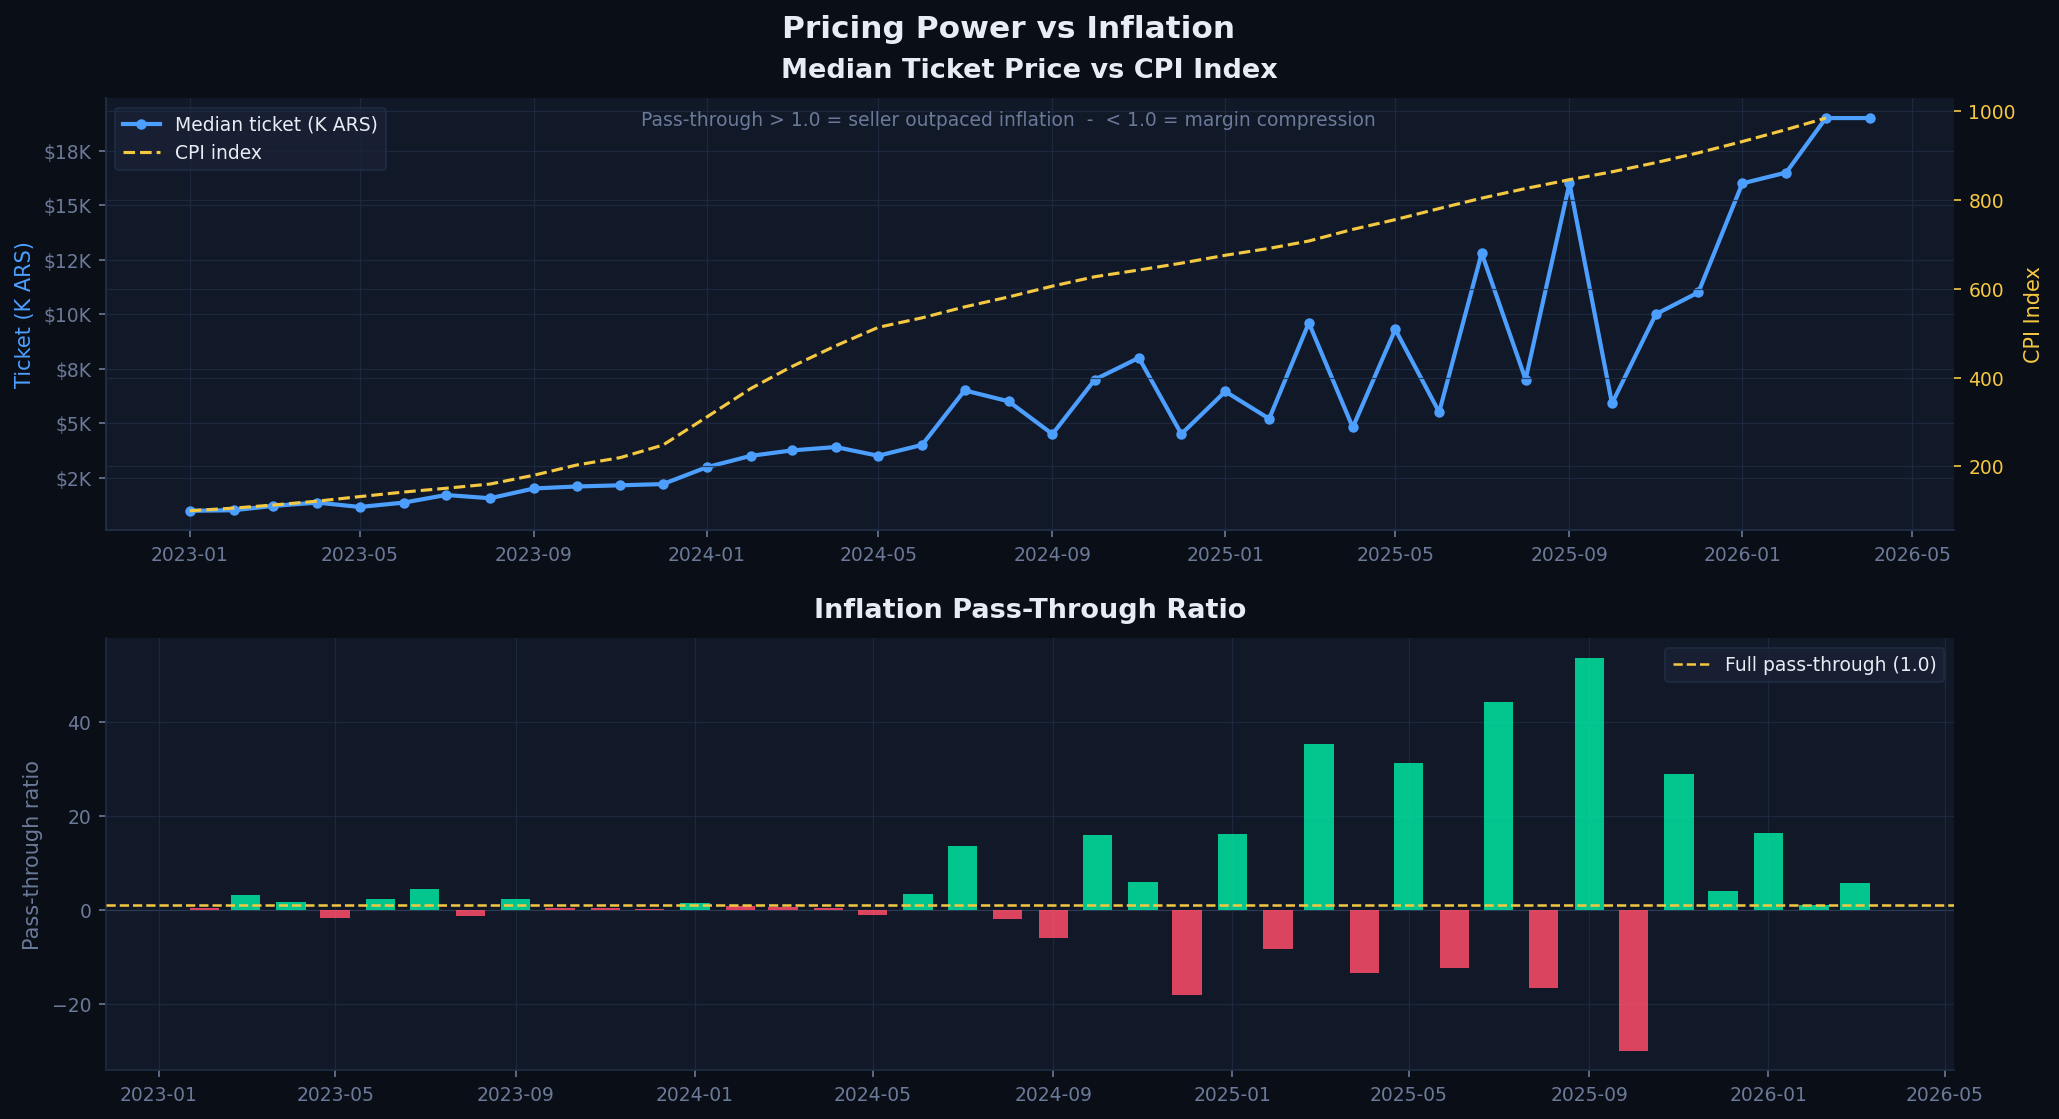

Average pass-through ratio: 4.78
Months with pricing power: 20/38 (53%)
Interpretation: seller maintained pricing power on average


In [7]:
# Inflation pass-through: how much of CPI ended up in seller's prices?
monthly_price = (
    df.groupby("year_month")
    .agg(
        median_price_nom = ("unit_price", "median"),
        median_price_rl = ("unit_price_real", "median"),
        cpi = ("cpi_index", "mean"),
    )
    .reset_index()
)
monthly_price["date"] = monthly_price["year_month"].dt.to_timestamp()
monthly_price["price_change_pct"] = monthly_price["median_price_nom"].pct_change() * 100
monthly_price["cpi_change_pct"] = monthly_price["cpi"].pct_change() * 100
monthly_price["pass_through"] = (
    monthly_price["price_change_pct"] / monthly_price["cpi_change_pct"]
).replace([np.inf, -np.inf], np.nan)

fig = plt.figure(figsize=(14, 8), facecolor=C["bg"])
fig.text(0.5, 0.98, "Pricing Power vs Inflation",
         ha="center", va="top", fontsize=15, fontweight="bold", color=C["text"])
fig.text(0.5, 0.90,
         "Pass-through > 1.0 = seller outpaced inflation  -  < 1.0 = margin compression",
         ha="center", va="top", fontsize=9, color=C["muted"])

ax1 = fig.add_axes([0.07, 0.55, 0.88, 0.36])
ax2 = fig.add_axes([0.07, 0.10, 0.88, 0.36])

# Panel 1: ticket vs CPI
ax1_r = ax1.twinx()
ax1.plot(monthly_price["date"], monthly_price["median_price_nom"] / 1e3,
         color=C["blue"], lw=2, marker="o", markersize=4, label="Median ticket (K ARS)")
ax1_r.plot(monthly_price["date"], monthly_price["cpi"],
           color=C["gold"], lw=1.5, ls="--", label="CPI index")
ax1.set_title("Median Ticket Price vs CPI Index", pad=10)
ax1.set_ylabel("Ticket (K ARS)", color=C["blue"])
ax1_r.set_ylabel("CPI Index", color=C["gold"])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax1_r.tick_params(colors=C["gold"])
ax1.set_facecolor(C["surface"])
spine_style(ax1)
ax1_r.spines["right"].set_color(C["border"])
lines = ax1.get_lines() + ax1_r.get_lines()
ax1.legend(lines, [ln.get_label() for ln in lines], loc="upper left")

# Panel 2: pass-through ratio
pt_vals  = monthly_price["pass_through"].iloc[1:]
pt_dates = monthly_price["date"].iloc[1:]
pt_colors = [C["accent"] if v >= 1 else C["red"] for v in pt_vals.fillna(0)]
ax2.bar(pt_dates, pt_vals, width=20, color=pt_colors, alpha=0.85, zorder=2)
ax2.axhline(1.0, color=C["gold"], lw=1.2, ls="--",
            label="Full pass-through (1.0)", zorder=3)
ax2.axhline(0.0, color=C["muted"], lw=0.5, zorder=1)
ax2.set_title("Inflation Pass-Through Ratio", pad=10)
ax2.set_ylabel("Pass-through ratio", color=C["muted"])
ax2.legend(loc="upper right")
ax2.set_facecolor(C["surface"])
spine_style(ax2)

plt.savefig(ROOT / "plots" / "09_pricing_power.png", dpi=150,
            bbox_inches="tight", facecolor=C["bg"])
plt.show()

pt_clean = monthly_price["pass_through"].dropna()
avg_pt   = pt_clean.mean()
months_above = (pt_clean >= 1).sum()
print(f"Average pass-through ratio: {avg_pt:.2f}")
print(f"Months with pricing power: {months_above}/{len(pt_clean)} ({months_above/len(pt_clean)*100:.0f}%)")
print(f"Interpretation: seller {'maintained pricing power on average' if avg_pt >= 1 else 'absorbed inflation on average — margin compression'}")


## Geographic Analysis

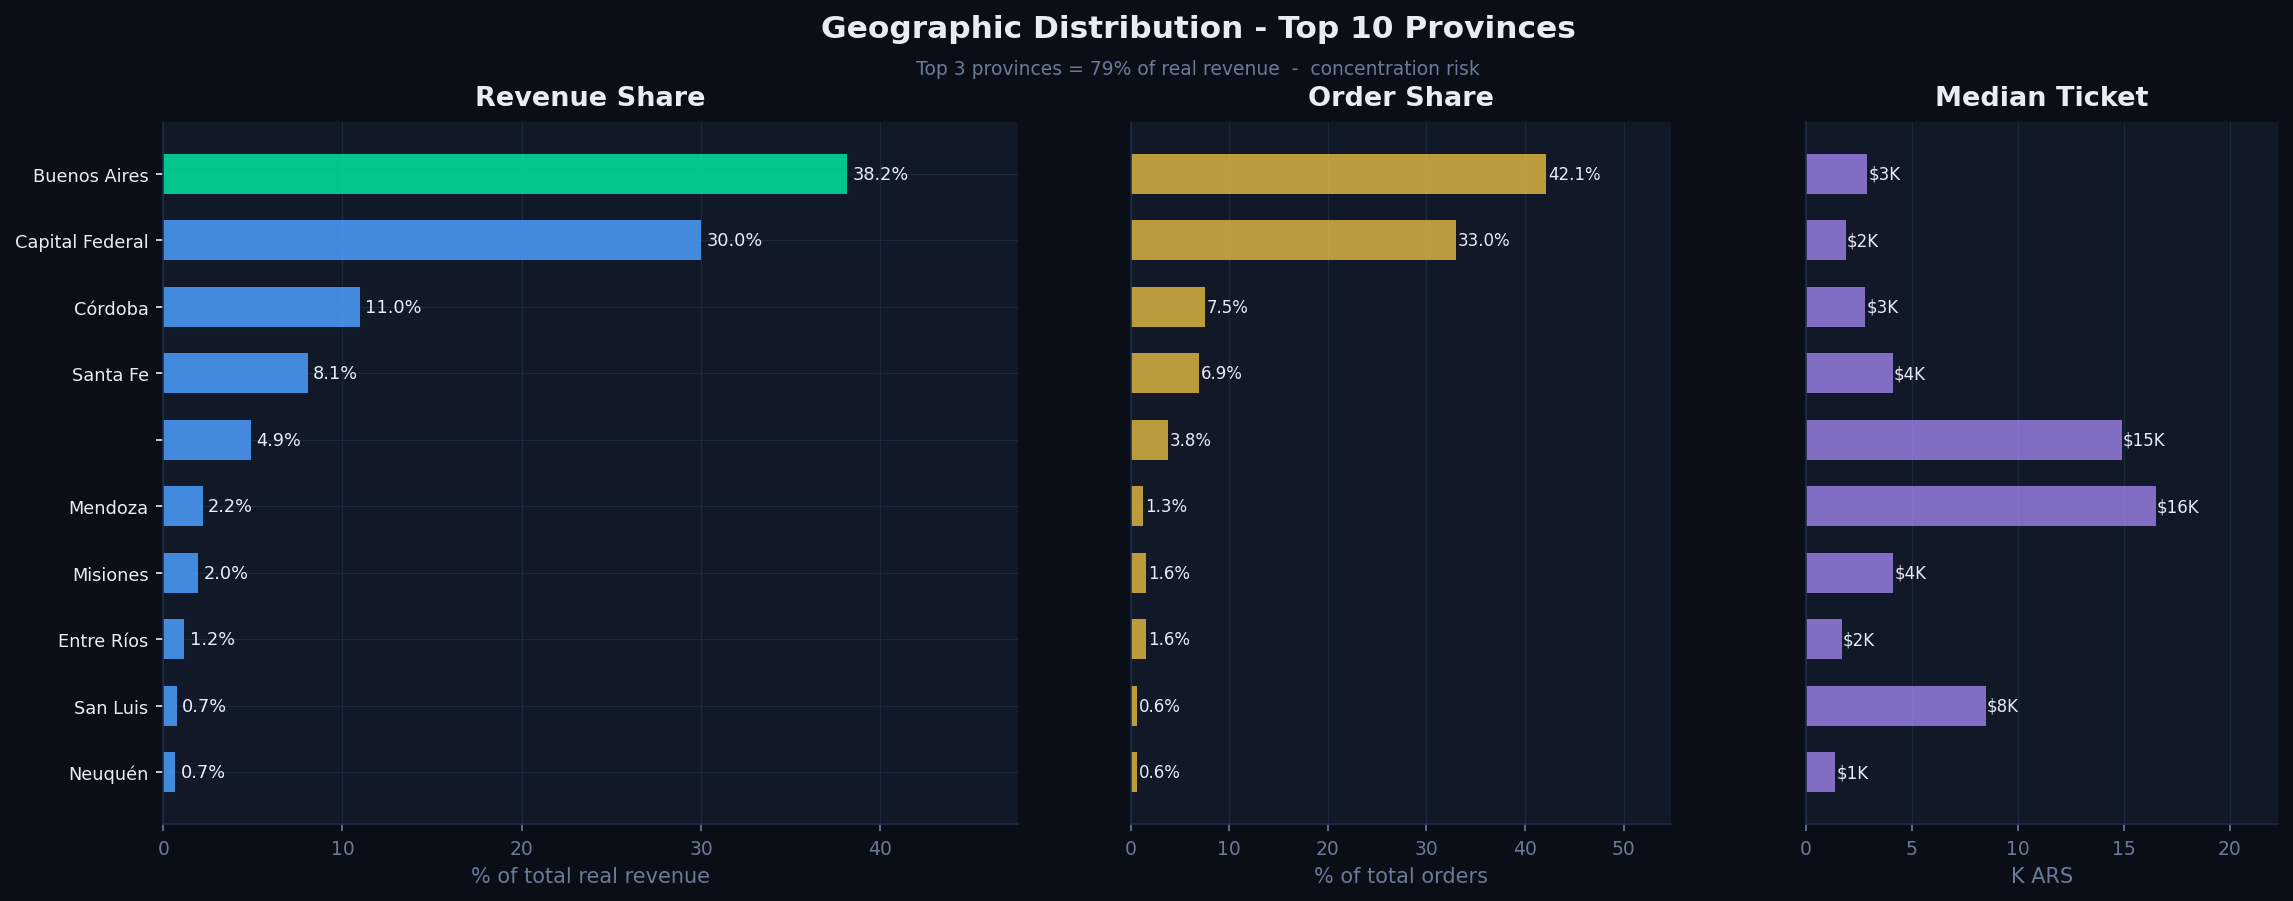

Top 3 provinces: 79.1% of revenue (concentration risk)
Total provinces: 13

       province  orders  revenue_share  order_share  median_ticket
   Buenos Aires     134      38.154936    42.138365         2899.5
Capital Federal     105      30.024466    33.018868         1899.0
        Córdoba      24      10.954826     7.547170         2799.5
       Santa Fe      22       8.052554     6.918239         4099.0
                     12       4.892174     3.773585        14898.5
        Mendoza       4       2.194740     1.257862        16499.0
       Misiones       5       1.958765     1.572327         4130.0
     Entre Ríos       5       1.168317     1.572327         1699.0


In [8]:
geo = (
    df.groupby("province")
    .agg(
        orders = ("order_id", "count"),
        gross_revenue = ("gross_revenue_real", "sum"),
        median_ticket = ("unit_price", "median"),
    )
    .reset_index()
    .dropna(subset=["province"])
    .sort_values("gross_revenue", ascending=False)
)
geo["revenue_share"] = geo["gross_revenue"] / geo["gross_revenue"].sum() * 100
geo["order_share"] = geo["orders"]  / geo["orders"].sum() * 100
geo["cum_rev_share"] = geo["revenue_share"].cumsum()
top10 = geo.head(10).sort_values("gross_revenue")   

fig = plt.figure(figsize=(15, 6), facecolor=C["bg"])
fig.text(0.5, 0.98, "Geographic Distribution - Top 10 Provinces",
         ha="center", va="top", fontsize=15, fontweight="bold", color=C["text"])
pct_top3 = geo.head(3)["revenue_share"].sum()
fig.text(0.5, 0.93, f"Top 3 provinces = {pct_top3:.0f}% of real revenue  -  concentration risk",
         ha="center", va="top", fontsize=9, color=C["muted"])

ax1 = fig.add_axes([0.04, 0.08, 0.38, 0.78])
ax2 = fig.add_axes([0.47, 0.08, 0.24, 0.78])
ax3 = fig.add_axes([0.77, 0.08, 0.21, 0.78])

# Revenue share
n = len(top10)
rev_colors = [C["accent"] if i == n-1 else C["blue"] for i in range(n)]
bars1 = ax1.barh(top10["province"], top10["revenue_share"],
                 color=rev_colors, alpha=0.85, height=0.6, zorder=2)
for bar, (_, row) in zip(bars1, top10.iterrows()):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{row['revenue_share']:.1f}%", va="center", fontsize=8.5, color=C["text"])
ax1.set_title("Revenue Share", pad=8)
ax1.set_xlabel("% of total real revenue", color=C["muted"])
ax1.set_facecolor(C["surface"])
spine_style(ax1)
ax1.set_xlim(0, top10["revenue_share"].max() * 1.25)
ax1.tick_params(axis="y", colors=C["text"], labelsize=8.5)

# Order share
bars2 = ax2.barh(top10["province"], top10["order_share"],
                 color=C["gold"], alpha=0.75, height=0.6, zorder=2)
for bar, (_, row) in zip(bars2, top10.iterrows()):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"{row['order_share']:.1f}%", va="center", fontsize=8, color=C["text"])
ax2.set_title("Order Share", pad=8)
ax2.set_xlabel("% of total orders", color=C["muted"])
ax2.set_facecolor(C["surface"])
spine_style(ax2)
ax2.set_yticks([])
ax2.set_xlim(0, top10["order_share"].max() * 1.3)

# Median ticket
bars3 = ax3.barh(top10["province"], top10["median_ticket"] / 1e3,
                 color=C["purple"], alpha=0.75, height=0.6, zorder=2)
for bar, (_, row) in zip(bars3, top10.iterrows()):
    ax3.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             fmt_ars(row["median_ticket"]), va="center", fontsize=8, color=C["text"])
ax3.set_title("Median Ticket", pad=8)
ax3.set_xlabel("K ARS", color=C["muted"])
ax3.set_facecolor(C["surface"])
spine_style(ax3)
ax3.set_yticks([])
ax3.set_xlim(0, top10["median_ticket"].max() / 1e3 * 1.35)

top3_rev_share = geo.head(3)["revenue_share"].sum()
plt.savefig(ROOT / "plots" / "10_geographic.png", dpi=150,
            bbox_inches="tight", facecolor=C["bg"])
plt.show()

print(f"Top 3 provinces: {top3_rev_share:.1f}% of revenue (concentration risk)")
print(f"Total provinces: {geo['province'].nunique()}")
print()
print(geo[["province","orders","revenue_share","order_share","median_ticket"]].head(8).to_string(index=False))


## Product Catalog Analysis

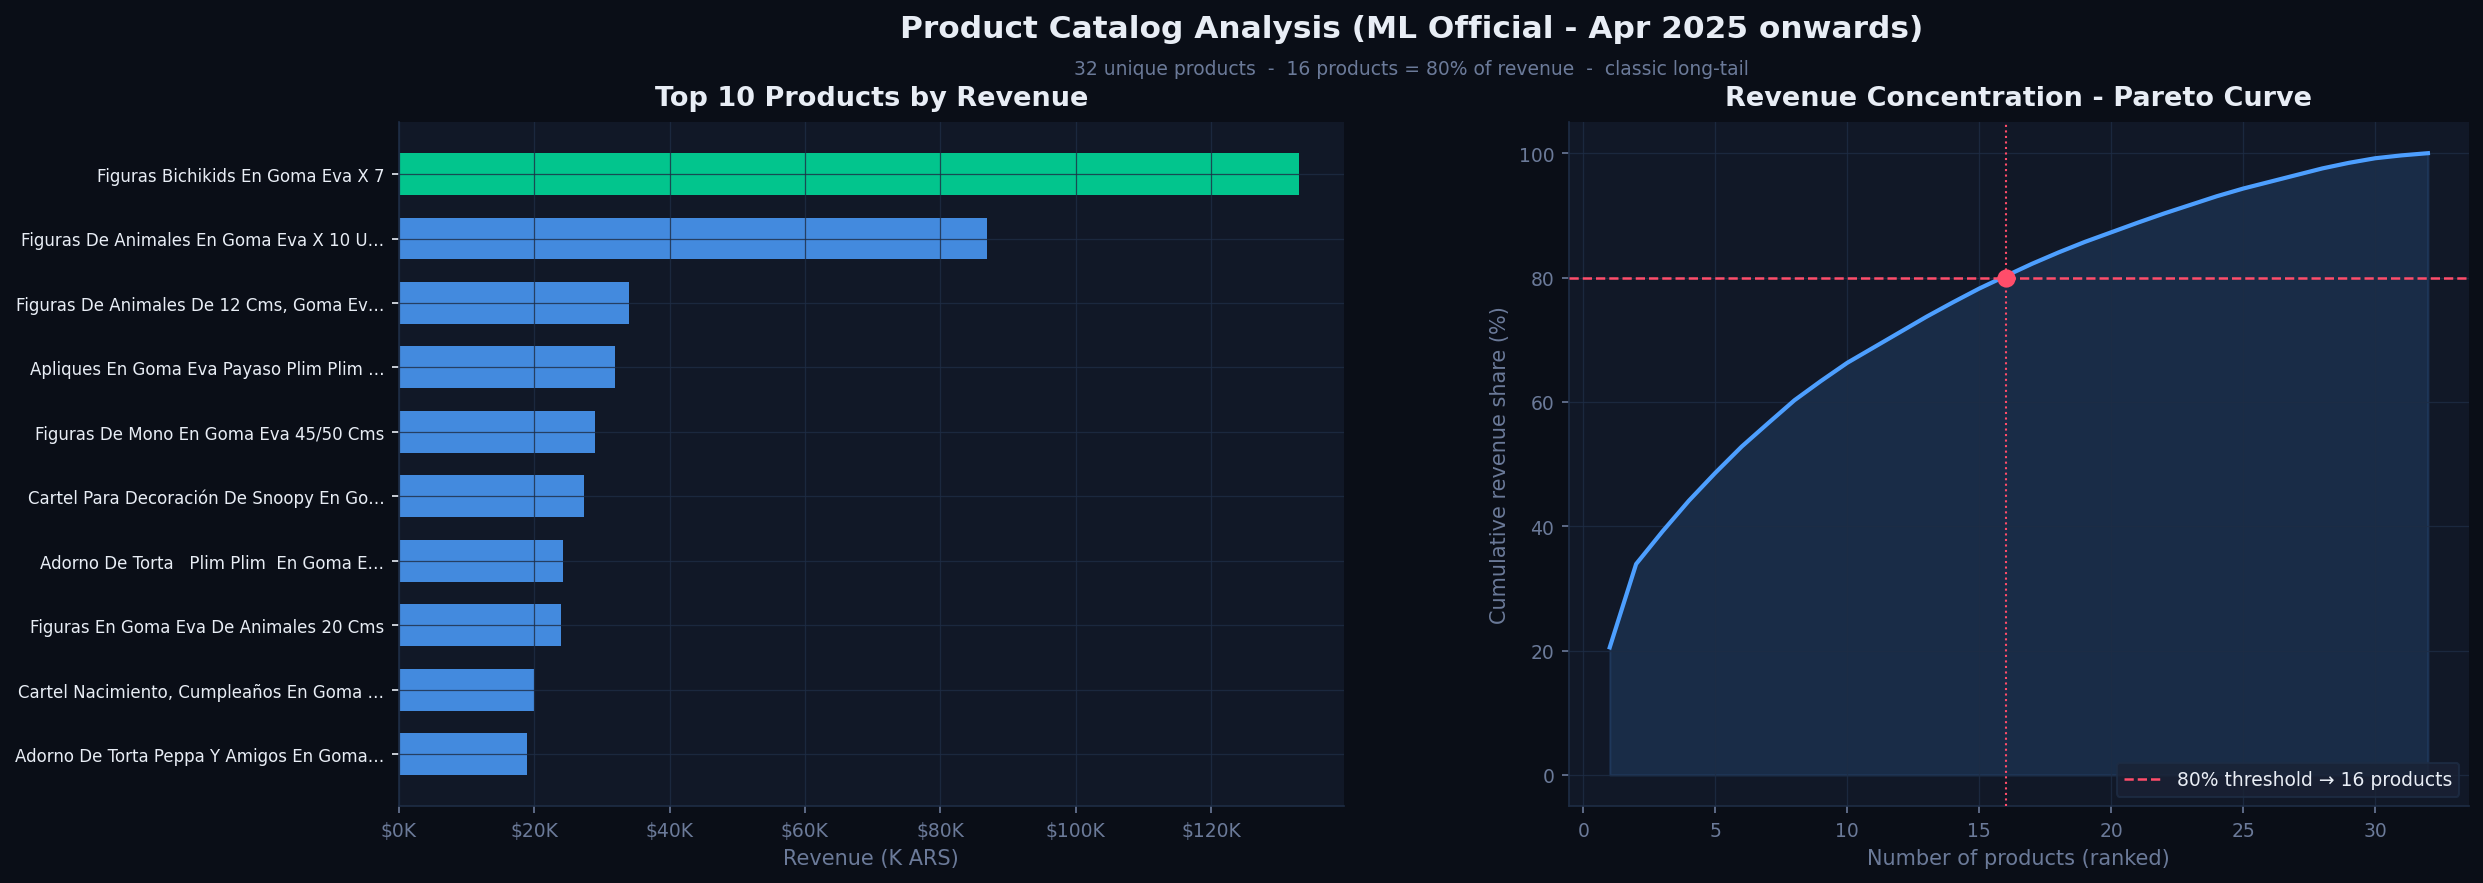

Unique products: 32
Products for 80% revenue: 16 (50% of catalog)

Top 5 by revenue:
                                  product_title  orders  revenue  revenue_share
              Figuras Bichikids En Goma Eva X 7       8 132992.8      20.522510
  Figuras De Animales En Goma Eva X 10 Unidades       6  86892.4      13.408622
Figuras De Animales De 12 Cms, Goma Eva, X 10 U       2  33998.0       5.246331
   Apliques En Goma Eva Payaso Plim Plim X 10u.       2  31998.0       4.937705
          Figuras De Mono En Goma Eva 45/50 Cms       1  29000.0       4.475075


In [9]:
df_ml = df[df["product_title"].notna() & (df["product_title"] != "nan")].copy()

if len(df_ml) == 0:
    print("No product title data available : skipping catalog analysis.")
else:
    catalog = (
        df_ml.groupby("product_title")
        .agg(
            orders = ("order_id", "count"),
            revenue = ("gross_revenue", "sum"),
            median_price = ("unit_price", "median"),
            total_units = ("quantity", "sum"),
        )
        .sort_values("revenue", ascending=False)
        .reset_index()
    )
    catalog["revenue_share"] = catalog["revenue"] / catalog["revenue"].sum() * 100
    catalog["cumulative_share"] = catalog["revenue_share"].cumsum()

    fig = plt.figure(figsize=(15, 6), facecolor=C["bg"])
    fig.text(0.5, 0.98, "Product Catalog Analysis (ML Official - Apr 2025 onwards)",
             ha="center", va="top", fontsize=15, fontweight="bold", color=C["text"])
    n80 = (catalog["cumulative_share"] <= 80).sum() + 1
    fig.text(0.5, 0.93,
             f"{len(catalog)} unique products  -  {n80} products = 80% of revenue  -  classic long-tail",
             ha="center", va="top", fontsize=9, color=C["muted"])

    ax1 = fig.add_axes([0.05, 0.10, 0.42, 0.76])
    ax2 = fig.add_axes([0.57, 0.10, 0.40, 0.76])

    # Top 10 by revenue
    top10_cat = catalog.head(10).sort_values("revenue")
    labels = [t[:38] + "…" if len(t) > 38 else t for t in top10_cat["product_title"]]
    n = len(top10_cat)
    bar_colors = [C["accent"] if i == n-1 else C["blue"] for i in range(n)]
    ax1.barh(labels, top10_cat["revenue"] / 1e3, color=bar_colors, alpha=0.85, height=0.65)
    ax1.set_title("Top 10 Products by Revenue", pad=8)
    ax1.set_xlabel("Revenue (K ARS)", color=C["muted"])
    ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
    ax1.set_facecolor(C["surface"])
    spine_style(ax1)
    ax1.tick_params(axis="y", colors=C["text"], labelsize=8)

    # Pareto curve
    n_prod = range(1, len(catalog) + 1)
    ax2.fill_between(list(n_prod), catalog["cumulative_share"],
                     alpha=0.15, color=C["blue"], zorder=1)
    ax2.plot(list(n_prod), catalog["cumulative_share"],
             color=C["blue"], lw=2, zorder=2)
    ax2.axhline(80, color=C["red"], ls="--", lw=1.2,
                label=f"80% threshold → {n80} products", zorder=3)
    ax2.axvline(n80, color=C["red"], ls=":", lw=1, zorder=3)
    ax2.scatter([n80], [80], color=C["red"], s=60, zorder=4)
    ax2.set_title("Revenue Concentration - Pareto Curve", pad=8)
    ax2.set_xlabel("Number of products (ranked)", color=C["muted"])
    ax2.set_ylabel("Cumulative revenue share (%)", color=C["muted"])
    ax2.legend(loc="lower right")
    ax2.set_facecolor(C["surface"])
    spine_style(ax2)

    plt.savefig(ROOT / "plots" / "11_catalog.png", dpi=150,
                bbox_inches="tight", facecolor=C["bg"])
    plt.show()

    print(f"Unique products: {len(catalog)}")
    print(f"Products for 80% revenue: {n80} ({n80/len(catalog)*100:.0f}% of catalog)")
    print()
    print("Top 5 by revenue:")
    print(catalog[["product_title","orders","revenue","revenue_share"]].head(5).to_string(index=False))


## Correlation Matrix

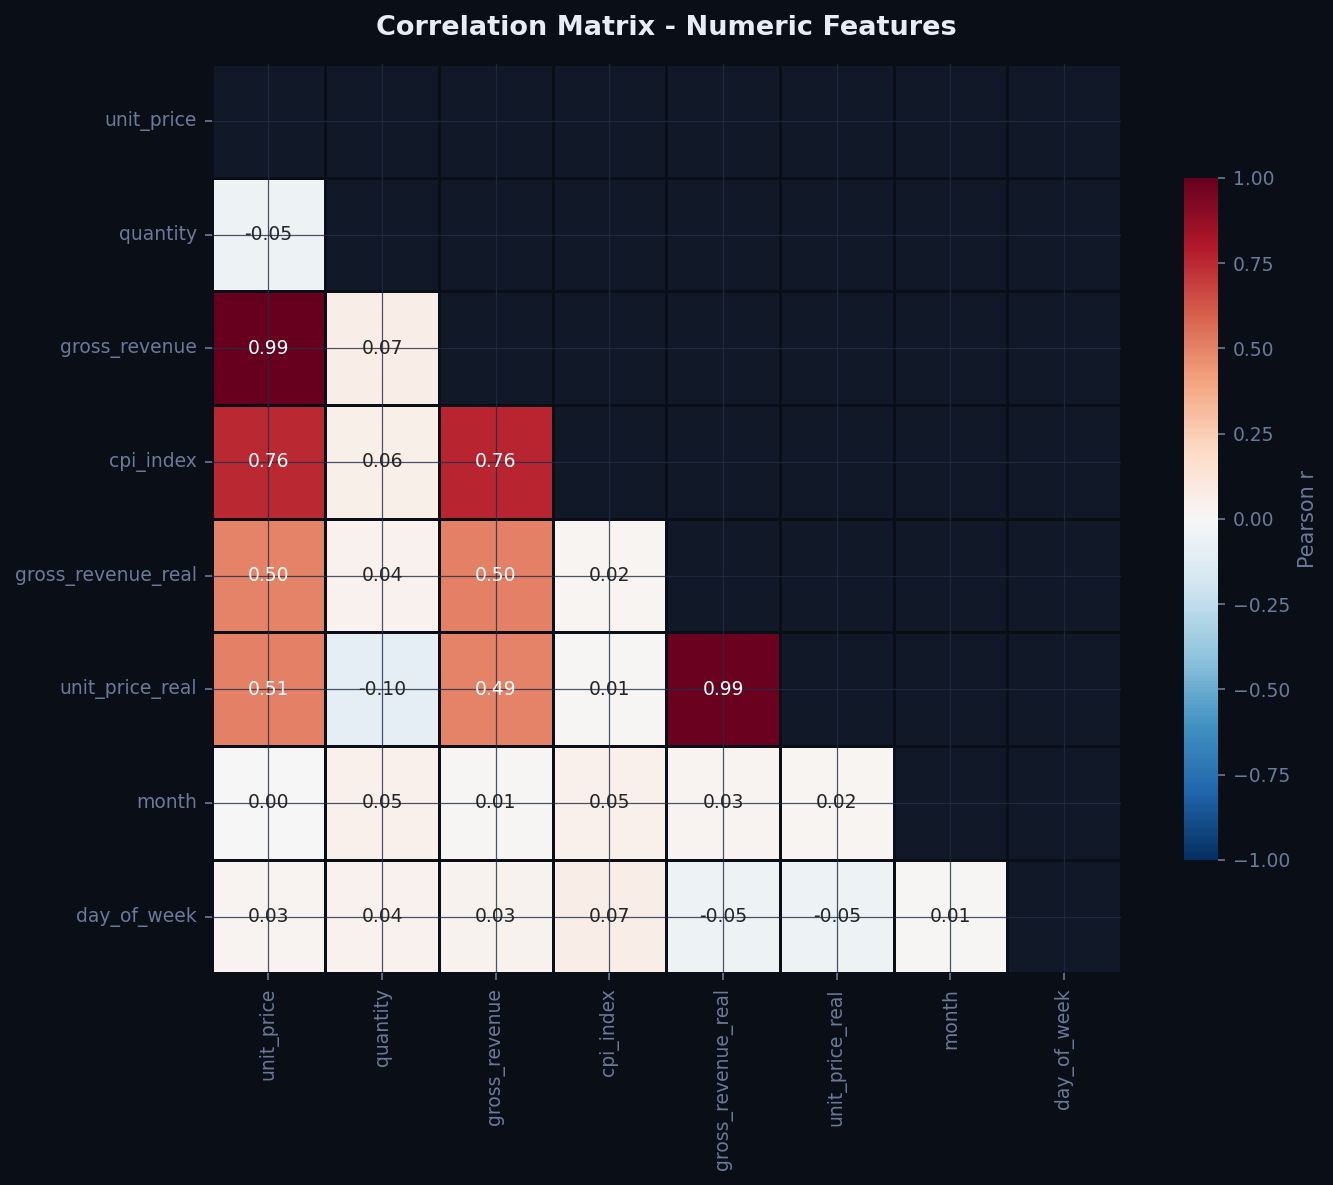

Strong correlations (|r| > 0.6, excl. self):
gross_revenue x unit_price: r = 0.99
cpi_index x unit_price: r = 0.76
cpi_index x gross_revenue: r = 0.76
unit_price_real x gross_revenue_real: r = 0.99


In [10]:
num_cols = ["unit_price", "quantity", "gross_revenue", "cpi_index",
            "gross_revenue_real", "unit_price_real", "month", "day_of_week"]

corr_df = df[num_cols].dropna()
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8), facecolor=C["bg"])
ax.set_facecolor(C["surface"])
fig.patch.set_facecolor(C["bg"])

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", linewidths=0.6, linecolor=C["bg"],
    square=True,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
)
ax.set_title("Correlation Matrix - Numeric Features",
             fontsize=13, fontweight="bold", color=C["text"], pad=14)
ax.tick_params(colors=C["muted"], labelsize=9)

plt.tight_layout()
plt.savefig(ROOT / "plots" / "12_correlation.png", dpi=150,
            bbox_inches="tight", facecolor=C["bg"])
plt.show()

print("Strong correlations (|r| > 0.6, excl. self):")
for col in corr.columns:
    for row in corr.index:
        if col != row and abs(corr.loc[row, col]) > 0.6:
            if list(corr.columns).index(col) < list(corr.columns).index(row):
                print(f"{row} x {col}: r = {corr.loc[row, col]:.2f}")


## Key Findings 

In [11]:
print("-KEY FINDINGS-")

# Revenue
nominal_g = (monthly["gross_nominal"].iloc[-1] / monthly["gross_nominal"].iloc[0] - 1) * 100
real_g = (monthly["gross_real"].dropna().iloc[-1] / monthly["gross_real"].dropna().iloc[0] - 1) * 100
print("\n[REVENUE]")
print(f"Nominal growth (full period): +{nominal_g:.0f}%")
print(f"Real growth (full period): {real_g:+.0f}%")

# Seasonality
peak_month = by_month.loc[by_month["gross_revenue_real"].idxmax(), "month_name"]
trough = by_month.loc[by_month["gross_revenue_real"].idxmin(), "month_name"]
print("\n[SEASONALITY]")
print(f"Peak month: {peak_month}")
print(f"Trough month: {trough}")
print(f"Weekend share: {wknd_pct:.1f}% of total orders")

# Pricing
print("\n[PRICING]")
print(f"Median ticket : ${df['unit_price'].median():,.0f} ARS (nominal)")
print(f"Avg pass-through ratio: {avg_pt:.2f} ({'pricing power' if avg_pt >= 1 else 'margin compression'})")

# Geography
print("\n[GEOGRAPHY]")
print(f"Top 3 provinces: {top3_rev_share:.1f}% of revenue (concentration risk)")
print(f"Total provinces: {geo['province'].nunique()}")

print("\n[WHAT THIS MEANS FOR DOWNSTREAM NOTEBOOKS]")
print(" -> 03_rfm_segmentation : order_id + date + gross_revenue")
print(" -> 04_demand_forecasting : monthly real revenue; seasonality signal is clear")
print(" -> 05_price_elasticity : unit_price_real + quantity; pricing power varies by period")
print(" -> 06_ab_testing : weekend vs weekday as natural experiment candidate")
print(" -> 07_cohort_analysis : date + order_id for retention curves")

print("\n[PLOTS SAVED]")
for name in ["05_nominal_vs_real","06_seasonality","07_day_of_week",
             "08_pricing_distribution","09_pricing_power",
             "10_geographic","11_catalog","12_correlation"]:
    p = ROOT / "plots" / f"{name}.png"
    status = "PASS" if p.exists() else "MISSING"
    print(f"{status}  plots/{name}.png")


-KEY FINDINGS-

[REVENUE]
Nominal growth (full period): +-15%
Real growth (full period): -100%

[SEASONALITY]
Peak month: Sep
Trough month: Oct
Weekend share: 24.4% of total orders

[PRICING]
Median ticket : $2,890 ARS (nominal)
Avg pass-through ratio: 4.78 (pricing power)

[GEOGRAPHY]
Top 3 provinces: 79.1% of revenue (concentration risk)
Total provinces: 13

[WHAT THIS MEANS FOR DOWNSTREAM NOTEBOOKS]
 -> 03_rfm_segmentation : order_id + date + gross_revenue
 -> 04_demand_forecasting : monthly real revenue; seasonality signal is clear
 -> 05_price_elasticity : unit_price_real + quantity; pricing power varies by period
 -> 06_ab_testing : weekend vs weekday as natural experiment candidate
 -> 07_cohort_analysis : date + order_id for retention curves

[PLOTS SAVED]
PASS  plots/05_nominal_vs_real.png
PASS  plots/06_seasonality.png
PASS  plots/07_day_of_week.png
PASS  plots/08_pricing_distribution.png
PASS  plots/09_pricing_power.png
PASS  plots/10_geographic.png
PASS  plots/11_catalog.pn